In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from datascience import *
from datetime import datetime
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
!pip install seaborn #Use 'pip' tool to install the seaborn library
import seaborn as sns
!pip install --upgrade scikit-learn #Use 'pip' tool to install the scikit-learn library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler , MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.multioutput import MultiOutputClassifier

In [ ]:
# Reading data
data=Table.read_table("/content/crimes of the UA 30K.csv")
data.show(5)

DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,nan,0,M,O,101,STREET,nan,nan,AA,Adult Arrest,510,998,nan,nan,1900 S LONGWOOD AV,nan,34.0375,-118.351
200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128,BUS STOP/LAYOVER (ALSO QUERY 124),nan,nan,IC,Invest Cont,330,998,nan,nan,1000 S FLOWER ST,nan,34.0444,-118.263
200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",nan,nan,IC,Invest Cont,480,nan,nan,nan,1400 W 37TH ST,nan,34.021,-118.3
200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405,CLOTHING STORE,nan,nan,IC,Invest Cont,343,nan,nan,nan,14000 RIVERSIDE DR,nan,34.1576,-118.439
200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,nan,0,nan,nan,101,STREET,nan,nan,IC,Invest Cont,510,nan,nan,nan,200 E AVENUE 28,nan,34.082,-118.213


In [ ]:
data.num_rows

30245

In [ ]:
data.num_columns

28

# 1. Data cleaning

In [ ]:
# Removing unnecessary columns
data = data.drop('DR_NO','Date Rptd', 'AREA', 'Rpt Dist No', 'Crm Cd', 'Mocodes', 'Vict Descent', 'Premis Cd',
                 'Weapon Used Cd', 'Status', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street',
                 'LAT', 'LON','Premis Desc', 'Status Desc')
data.show(5)

DATE OCC,TIME OCC,AREA NAME,Part 1-2,Crm Cd Desc,Vict Age,Vict Sex,Weapon Desc
3/1/2020 0:00,2130,Wilshire,1,VEHICLE - STOLEN,0,M,nan
2/8/2020 0:00,1800,Central,1,BURGLARY FROM VEHICLE,47,M,nan
11/4/2020 0:00,1700,Southwest,1,BIKE - STOLEN,19,X,nan
3/10/2020 0:00,2037,Van Nuys,1,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,nan
9/9/2020 0:00,630,Hollenbeck,1,VEHICLE - STOLEN,0,nan,nan


In [ ]:
# Removing duplicate rows
data_df = data.to_df()
data_df = data_df.drop_duplicates()
data = Table.from_df(data_df)
data.show(5)

DATE OCC,TIME OCC,AREA NAME,Part 1-2,Crm Cd Desc,Vict Age,Vict Sex,Weapon Desc
3/1/2020 0:00,2130,Wilshire,1,VEHICLE - STOLEN,0,M,nan
2/8/2020 0:00,1800,Central,1,BURGLARY FROM VEHICLE,47,M,nan
11/4/2020 0:00,1700,Southwest,1,BIKE - STOLEN,19,X,nan
3/10/2020 0:00,2037,Van Nuys,1,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,nan
9/9/2020 0:00,630,Hollenbeck,1,VEHICLE - STOLEN,0,nan,nan


In [ ]:
#  Renaming columns
data = data.relabeled('DATE OCC', 'Date')
data = data.relabeled('TIME OCC', 'Time')
data = data.relabeled('AREA NAME', 'Area')
data = data.relabeled('Part 1-2', 'Serious')
data = data.relabeled('Crm Cd Desc', 'Type of crime')
data = data.relabeled('Weapon Desc', 'Weapon')
data.show(5)

Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon
3/1/2020 0:00,2130,Wilshire,1,VEHICLE - STOLEN,0,M,nan
2/8/2020 0:00,1800,Central,1,BURGLARY FROM VEHICLE,47,M,nan
11/4/2020 0:00,1700,Southwest,1,BIKE - STOLEN,19,X,nan
3/10/2020 0:00,2037,Van Nuys,1,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19,M,nan
9/9/2020 0:00,630,Hollenbeck,1,VEHICLE - STOLEN,0,nan,nan


In [ ]:
# Dealting missing values
def filter_all_columns(data):
    invalid_values = ["nan", '', 0, np.nan,'UNKNOWN WEAPON/OTHER WEAPON']
    for column in data.labels:
      if column in ['Date', 'Time', 'Area', 'Type of crime', 'Status','Vict Age', 'Vict Sex','Weapon']:
        data = data.where(column, lambda value: value not in invalid_values)
    return data

data = filter_all_columns(data)
data.show(5)

Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon
5/10/2020 0:00,2200,Central,2,INTIMATE PARTNER - SIMPLE ASSAULT,30,F,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)"
12/2/2020 0:00,2245,77th Street,1,ROBBERY,21,M,VERBAL THREAT
5/1/2020 0:00,2330,77th Street,1,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",28,F,KNIFE WITH BLADE OVER 6 INCHES IN LENGTH
1/18/2020 0:00,940,Central,2,BATTERY - SIMPLE ASSAULT,42,M,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)"
8/27/2020 0:00,1255,Van Nuys,2,BATTERY - SIMPLE ASSAULT,57,F,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)"


In [ ]:
# Find all unique values within a specific column
def unique_values(colm):
  for column in data.labels:
     unique_values = np.unique(data.column(colm))
     return unique_values

# Replace values within a column by provided mapping
def rename_values(column, mapping):
    return [mapping.get(value, value) for value in column]

In [ ]:
# Display all distinct values present in 'Area' column
unique_values('Area')

array(['77th Street', 'Central', 'Devonshire', 'Foothill', 'Harbor',
       'Hollenbeck', 'Hollywood', 'Mission', 'N Hollywood', 'Newton',
       'Northeast', 'Olympic', 'Pacific', 'Rampart', 'Southeast',
       'Southwest', 'Topanga', 'Van Nuys', 'West LA', 'West Valley',
       'Wilshire'],
      dtype='<U11')

In [ ]:
# Combining variations into more common forms
data = data.with_column('Area', data.apply(lambda x: 'Hollywood' if x == 'N Hollywood' else ('West LA' if x == 'West Valley' else x), 'Area'))
unique_values('Area')

array(['77th Street', 'Central', 'Devonshire', 'Foothill', 'Harbor',
       'Hollenbeck', 'Hollywood', 'Mission', 'Newton', 'Northeast',
       'Olympic', 'Pacific', 'Rampart', 'Southeast', 'Southwest',
       'Topanga', 'Van Nuys', 'West LA', 'Wilshire'],
      dtype='<U11')

In [ ]:
# Display all distinct values present in 'Serious' column
unique_values('Serious')

array([1, 2])

In [ ]:
# Converting numerical representation in 'Serious' column into more readable categorical representation ('Yes' or 'No').
data = data.with_column('Serious', data.apply(lambda x: 'Yes' if x == 1 else 'No', 'Serious'))

data.show(5)

Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon
5/10/2020 0:00,2200,Central,No,INTIMATE PARTNER - SIMPLE ASSAULT,30,F,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)"
12/2/2020 0:00,2245,77th Street,Yes,ROBBERY,21,M,VERBAL THREAT
5/1/2020 0:00,2330,77th Street,Yes,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",28,F,KNIFE WITH BLADE OVER 6 INCHES IN LENGTH
1/18/2020 0:00,940,Central,No,BATTERY - SIMPLE ASSAULT,42,M,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)"
8/27/2020 0:00,1255,Van Nuys,No,BATTERY - SIMPLE ASSAULT,57,F,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)"


In [ ]:
# Display all distinct values present in 'Type of crime' column
unique_values('Type of crime')

array(['ARSON', 'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER',
       'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT',
       'ATTEMPTED ROBBERY', 'BATTERY - SIMPLE ASSAULT',
       'BATTERY POLICE (SIMPLE)', 'BATTERY WITH SEXUAL CONTACT',
       'BOMB SCARE', 'BRANDISH WEAPON', 'BUNCO, PETTY THEFT', 'BURGLARY',
       'BURGLARY FROM VEHICLE',
       'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT',
       'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT',
       'CHILD NEGLECT (SEE 300 W.I.C.)', 'CONTEMPT OF COURT',
       'CRIMINAL HOMICIDE', 'CRIMINAL THREATS - NO WEAPON DISPLAYED',
       'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)',
       'CRUELTY TO ANIMALS', 'DISCHARGE FIREARMS/SHOTS FIRED',
       'DISTURBING THE PEACE', 'EXTORTION',
       'INTIMATE PARTNER - AGGRAVATED ASSAULT',
       'INTIMATE PARTNER - SIMPLE ASSAULT', 'KIDNAPPING',
       'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD', 'LEWD CONDUCT',
       'ORAL COPULATION', 'OTHER ASSAULT', 'OTHER MISCELLANEOUS CRIME'

In [ ]:
# Combining variations into more common forms
type_mapping = {'ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER': 'VIOLENCE', 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 'VIOLENCE',
      'BATTERY - SIMPLE ASSAULT': 'VIOLENCE', 'BATTERY WITH SEXUAL CONTACT': 'BEHAVIORAL CRIME','BATTERY POLICE (SIMPLE)': 'BEHAVIORAL CRIME',
      'BATTERY ON A FIREFIGHTER': 'VIOLENCE', 'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT': 'VIOLENCE', 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT': 'BEHAVIORAL CRIME',
      'CRIMINAL HOMICIDE': 'VIOLENCE', 'CRIMINAL THREATS - NO WEAPON DISPLAYED': 'VIOLENCE', 'KIDNAPPING': 'VIOLENCE',  'RAPE, ATTEMPTED': 'TERRORIZATION',
      'RAPE, FORCIBLE' :  'VIOLENCE', 'ROBBERY':'VIOLENCE', 'SEXUAL PENETRATION W/FOREIGN OBJECT':'VIOLENCE', 'ATTEMPTED ROBBERY': 'THEFT', 'BURGLARY': 'THEFT',
      'BURGLARY FROM VEHICLE': 'THEFT', 'BURGLARY FROM VEHICLE, ATTEMPTED': 'THEFT', 'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'THEFT',
      'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)': 'THEFT', 'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)': 'THEFT','HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE':'VIOLENCE',
      'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)': 'THEFT', 'THEFT FROM PERSON - ATTEMPT': 'THEFT', 'THEFT OF IDENTITY': 'THEFT',
      'THEFT PLAIN - PETTY ($950 & UNDER)': 'THEFT', 'THEFT, PERSON': 'THEFT','THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD': 'THEFT',
      'ARSON': 'PROPERTY DAMAGES', 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 'PROPERTY DAMAGES','VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 'PROPERTY DAMAGES',
      'BIKE - STOLEN' :'THEFT','BOMB SCARE': 'TERRORIZATION', 'BRANDISH WEAPON': 'TERRORIZATION', 'BUNCO, ATTEMPT':'THEFT', 'BUNCO, GRAND THEFT':'THEFT', 'BUNCO, PETTY THEFT':'THEFT',
      'BURGLARY, ATTEMPTED' :'THEFT', 'CHILD ANNOYING (17YRS & UNDER)': 'BEHAVIORAL CRIME','CHILD NEGLECT (SEE 300 W.I.C.)': 'BEHAVIORAL CRIME',
      'CHILD PORNOGRAPHY' : 'BEHAVIORAL CRIME', 'CHILD STEALING':'TERRORIZATION', 'CONTEMPT OF COURT': 'BEHAVIORAL CRIME', 'COUNTERFEIT': 'THEFT',
      'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)': 'BEHAVIORAL CRIME', 'DISCHARGE FIREARMS/SHOTS FIRED': 'VIOLENCE', 'DISHONEST EMPLOYEE - GRAND THEFT': 'THEFT',
      'DISTURBING THE PEACE': 'TERRORIZATION', 'DOCUMENT FORGERY / STOLEN FELONY': 'THEFT','EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)': 'THEFT', 'EXTORTION':'BEHAVIORAL CRIME',
      'FAILURE TO YIELD': 'BEHAVIORAL CRIME', 'FALSE IMPRISONMENT':'VIOLENCE','HUMAN TRAFFICKING - COMMERCIAL SEX ACTS':'TERRORIZATION','INTIMATE PARTNER - AGGRAVATED ASSAULT': 'VIOLENCE',
      'INTIMATE PARTNER - SIMPLE ASSAULT': 'TERRORIZATION','LETTERS, LEWD  -  TELEPHONE CALLS, LEWD':'BEHAVIORAL CRIME', 'LEWD CONDUCT': 'BEHAVIORAL CRIME',
      'LEWD/LASCIVIOUS ACTS WITH CHILD': 'VIOLENCE','ORAL COPULATION': 'BEHAVIORAL CRIME', 'CONTRIBUTING': 'THEFT','INDECENT EXPOSURE':'BEHAVIORAL CRIME',
      'OTHER ASSAULT': 'VIOLENCE', 'OTHER MISCELLANEOUS CRIME':'TERRORIZATION','PANDERING':'BEHAVIORAL CRIME','PEEPING TOM': 'BEHAVIORAL CRIME','PICKPOCKET': 'THEFT',
      'PIMPING': 'BEHAVIORAL CRIME', 'RECKLESS DRIVING': 'PROPERTY DAMAGES','RESISTING ARREST': 'BEHAVIORAL CRIME', 'SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ':'BEHAVIORAL CRIME',
      'SHOTS FIRED AT INHABITED DWELLING':'VIOLENCE','SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT':'VIOLENCE','SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH':'BEHAVIORAL CRIME',
      'STALKING':'TERRORIZATION','THEFT FROM MOTOR VEHICLE - ATTEMPT': 'THEFT','THREATENING PHONE CALLS/LETTERS':'TERRORIZATION','THROWING OBJECT AT MOVING VEHICLE': 'VIOLENCE',
      'TRESPASSING': 'VIOLENCE','UNAUTHORIZED COMPUTER ACCESS':'THEFT','VEHICLE - ATTEMPT STOLEN': 'THEFT','VEHICLE - STOLEN': 'THEFT','DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER':'THEFT',
      'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)': 'THEFT', 'CREDIT CARDS, FRAUD USE ($950 & UNDER':'THEFT', 'CRUELTY TO ANIMALS':'VIOLENCE',
      'VIOLATION OF COURT ORDER':'BEHAVIORAL CRIME','VIOLATION OF RESTRAINING ORDER':'BEHAVIORAL CRIME','VIOLATION OF TEMPORARY RESTRAINING ORDER':'BEHAVIORAL CRIME',
      'KIDNAPPING - GRAND ATTEMPT': 'VIOLENCE', 'MANSLAUGHTER, NEGLIGENT':'VIOLENCE','PURSE SNATCHING': 'THEFT', 'TELEPHONE PROPERTY - DAMAGE': 'PROPERTY DAMAGES', 'THEFT PLAIN - ATTEMPT':'THEFT'
}
data = data.with_columns(
    'Type of crime', rename_values(data.column('Type of crime'), type_mapping))
unique_values('Type of crime')

array(['BEHAVIORAL CRIME', 'PROPERTY DAMAGES', 'TERRORIZATION', 'THEFT',
       'VIOLENCE'],
      dtype='<U16')

In [ ]:
# Display all distinct values present in 'Weapon' column
unique_values('Weapon')

array(['AIR PISTOL/REVOLVER/RIFLE/BB GUN', 'AXE',
       'BELT FLAILING INSTRUMENT/CHAIN', 'BLUNT INSTRUMENT', 'BOARD',
       'BOMB THREAT', 'BOTTLE', 'CAUSTIC CHEMICAL/POISON', 'CLEAVER',
       'CLUB/BAT', 'CONCRETE BLOCK/BRICK', 'FIRE', 'FIXED OBJECT',
       'FOLDING KNIFE', 'GLASS', 'HAMMER', 'HAND GUN',
       'HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE', 'ICE PICK',
       'KITCHEN KNIFE', 'KNIFE WITH BLADE 6INCHES OR LESS',
       'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH', 'MACE/PEPPER SPRAY',
       'MACHETE', 'OTHER CUTTING INSTRUMENT', 'OTHER FIREARM',
       'OTHER KNIFE', 'PHYSICAL PRESENCE', 'PIPE/METAL PIPE', 'RAZOR',
       'RAZOR BLADE', 'REVOLVER', 'ROCK/THROWN OBJECT', 'ROPE/LIGATURE',
       'SCALDING LIQUID', 'SCISSORS', 'SCREWDRIVER',
       'SEMI-AUTOMATIC PISTOL', 'SHOTGUN', 'SIMULATED GUN', 'STICK',
       'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)', 'STUN GUN',
       'SWITCH BLADE', 'SWORD', 'UNKNOWN FIREARM',
       'UNKNOWN TYPE CUTTING INSTRUMENT

In [ ]:
# Combining variations into more common forms
weapon_mapping = {
    'AIR PISTOL/REVOLVER/RIFLE/BB GUN': 'FIREARM','SCISSORS' : 'SHARP TOOL','GLASS' : 'SHARP TOOL',
    'HAND GUN': 'FIREARM', 'AXE':'SHARP TOOL','RAZOR BLADE': 'SHARP TOOL',
    'SHOTGUN': 'FIREARM', 'ICE PICK':'SHARP TOOL','CLEAVER' : 'SHARP TOOL',
    'PIPE/METAL PIPE': 'SHARP TOOL',
    'FOLDING KNIFE': 'SHARP TOOL','HECKLER & KOCH 93 SEMIAUTOMATIC ASSAULT RIFLE': 'FIREARM',
    'KITCHEN KNIFE': 'SHARP TOOL',
    'KNIFE' : 'SHARP TOOL', 'SCREWDRIVER': 'SHARP TOOL',
    'KNIFE WITH BLADE 6INCHES OR LESS': 'SHARP TOOL', 'DEMAND NOTE':'THREAT',
    'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH': 'SHARP TOOL',
    'MACHETE': 'SHARP TOOL', 'BRASS KNUCKLES': 'HEAVY OBJECT',
    'OTHER CUTTING INSTRUMENT': 'SHARP TOOL',
    'OTHER FIREARM': 'FIREARM',
    'OTHER KNIFE': 'SHARP TOOL', 'STUN GUN': 'FIREARM',
    'REVOLVER': 'FIREARM','SEMI-AUTOMATIC RIFLE':'FIREARM',
    'SEMI-AUTOMATIC PISTOL': 'FIREARM',
    'SIMULATED GUN': 'FIREARM','DIRK/DAGGER':'SHARP TOOL',
    'SWITCH BLADE': 'SHARP TOOL', 'TIRE IRON': 'HEAVY OBJECT',
    'SWORD': 'SHARP TOOL', 'BOWIE KNIFE':'SHARP TOOL',
    'UNKNOWN FIREARM': 'FIREARM','MARTIAL ARTS WEAPONS':'PHYSICAL VIOLENCE',
    'UNKNOWN TYPE CUTTING INSTRUMENT': 'SHARP TOOL',
    'RAZOR': 'SHARP TOOL','DOG/ANIMAL (SIC ANIMAL ON)':'PHYSICAL VIOLENCE',
    'BELT FLAILING INSTRUMENT/CHAIN':'ROPE/LIGATURE', 'BLUNT INSTRUMENT': 'SHARP TOOL',
    'SCALDING LIQUID': 'BORN', 'EXPLOXIVE DEVICE':'FIREARM',
    'FIRE': 'BORN', 'CLUB/BAT': 'HEAVY OBJECT', 'TOY GUN':'FIREARM',
    'CAUSTIC CHEMICAL/POISON':'BORN', 'RIFLE':'FIREARM',
    'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)' :'PHYSICAL VIOLENCE',
    'PHYSICAL PRESENCE': 'PHYSICAL VIOLENCE',
    'BOARD': 'HEAVY OBJECT', 'HAMMER': 'HEAVY OBJECT',
    'BOTTLE': 'HEAVY OBJECT', 'FIXED OBJECT': 'HEAVY OBJECT',
    'CONCRETE BLOCK/BRICK': 'HEAVY OBJECT', 'LIQUOR/DRUGS':'BORN',
    'ROCK/THROWN OBJECT': 'HEAVY OBJECT', 'MACE/PEPPER SPRAY':'BORN',
    'BOMB THREAT': 'THREAT', 'STICK':'HEAVY OBJECT', 'VEHICLE': 'HEAVY OBJECT',
    'VERBAL THREAT': 'THREAT',

}
data = data.with_columns("Weapon", rename_values(data.column("Weapon"), weapon_mapping))
unique_values('Weapon')

array(['BORN', 'FIREARM', 'HEAVY OBJECT', 'PHYSICAL VIOLENCE',
       'ROPE/LIGATURE', 'SHARP TOOL', 'THREAT'],
      dtype='<U17')

In [ ]:
# Dealting unwanted values
data = data.where('Vict Sex', lambda y: y not in ["X", np.nan])
# Replacing values for better readability
data = data.with_column('Vict Sex', data.apply(lambda Z: 'MALE' if Z == 'M' else 'FEMALE', 'Vict Sex'))

data.show(5)

Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon
5/10/2020 0:00,2200,Central,No,TERRORIZATION,30,FEMALE,PHYSICAL VIOLENCE
12/2/2020 0:00,2245,77th Street,Yes,VIOLENCE,21,MALE,THREAT
5/1/2020 0:00,2330,77th Street,Yes,VIOLENCE,28,FEMALE,SHARP TOOL
1/18/2020 0:00,940,Central,No,VIOLENCE,42,MALE,PHYSICAL VIOLENCE
8/27/2020 0:00,1255,Van Nuys,No,VIOLENCE,57,FEMALE,PHYSICAL VIOLENCE


In [ ]:
# Reformat Time from likely integer format into more standard '24-hour time' format
def format_time(value):
    value = str(value).zfill(4)
    hour = int(value[:2])
    minute = int(value[2:])
    formatted_time = f"{hour:02}:{minute:02}"
    return formatted_time

data = data.with_column("Time 24-form", data.apply(format_time, "Time"))
data.show(5)

Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon,Time 24-form
5/10/2020 0:00,2200,Central,No,TERRORIZATION,30,FEMALE,PHYSICAL VIOLENCE,22:00
12/2/2020 0:00,2245,77th Street,Yes,VIOLENCE,21,MALE,THREAT,22:45
5/1/2020 0:00,2330,77th Street,Yes,VIOLENCE,28,FEMALE,SHARP TOOL,23:30
1/18/2020 0:00,940,Central,No,VIOLENCE,42,MALE,PHYSICAL VIOLENCE,09:40
8/27/2020 0:00,1255,Van Nuys,No,VIOLENCE,57,FEMALE,PHYSICAL VIOLENCE,12:55


In [ ]:
# Takes 'Date' column that has both date and time and creates a new column with only the date
def extract_date_only(date_str):
    return datetime.strptime(date_str, "%m/%d/%Y %H:%M").strftime("%m/%d/%Y")

data = data.with_column("Date", data.apply(lambda d: extract_date_only(d), "Date"))
data.show(5)

Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon,Time 24-form
05/10/2020,2200,Central,No,TERRORIZATION,30,FEMALE,PHYSICAL VIOLENCE,22:00
12/02/2020,2245,77th Street,Yes,VIOLENCE,21,MALE,THREAT,22:45
05/01/2020,2330,77th Street,Yes,VIOLENCE,28,FEMALE,SHARP TOOL,23:30
01/18/2020,940,Central,No,VIOLENCE,42,MALE,PHYSICAL VIOLENCE,09:40
08/27/2020,1255,Van Nuys,No,VIOLENCE,57,FEMALE,PHYSICAL VIOLENCE,12:55


# 2. Data analysis

In [ ]:
# The frequency of different 'Type of crime'
num_of_typs = data.group('Type of crime')
num_of_typs

Type of crime,count
BEHAVIORAL CRIME,77
PROPERTY DAMAGES,21
TERRORIZATION,290
THEFT,43
VIOLENCE,1016


In [ ]:
# The frequency of different 'Area'
num_fo_crm_in_area = data.group('Area')
num_fo_crm_in_area

Area,count
77th Street,128
Central,83
Devonshire,51
Foothill,46
Harbor,64
Hollenbeck,34
Hollywood,141
Mission,89
Newton,70
Northeast,33


In [ ]:
# The frequency of 'Serious' column
is_it_serious = data.group('Serious')
is_it_serious

Serious,count
No,822
Yes,625


In [ ]:
# The frequency of 'Vict Sex' column
vict_sex = data.group('Vict Sex')
vict_sex

Vict Sex,count
FEMALE,740
MALE,707


In [ ]:
# The frequency of 'Weapon' column
Woeben_data= data.group('Weapon')
Woeben_data.show()

Weapon,count
BORN,23
FIREARM,174
HEAVY OBJECT,66
PHYSICAL VIOLENCE,911
ROPE/LIGATURE,6
SHARP TOOL,153
THREAT,114


In [ ]:
# Categorize the time of crimes into different time periods
# Defining Time Labels
time_labels = {
    0: '12AM - 3AM',
    300: '3AM - 6AM',
    600: '6AM - 9AM',
    900: '9AM - 12PM',
    1200: '12PM - 3PM',
    1500:'3PM - 6PM',
    1800: '6PM - 9PM',
    2100: '9PM - 12AM'
}
# Assigning Time Bins to Crimes
data_time = data.select("Time")
bins = [0, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]
def assign_time_bin(time):
    for i in range(len(bins) - 1):
        if bins[i] <= time < bins[i + 1]:
            return time_labels.get(bins[i], "Unknown")
    return time_labels.get(bins[-1], "Unknown")
data_time_binned = data_time.with_column("Time period", data_time.apply(assign_time_bin, "Time"))

data_time_binned.group("Time period")

Time period,count
12AM - 3AM,146
12PM - 3PM,214
3AM - 6AM,63
3PM - 6PM,245
6AM - 9AM,108
6PM - 9PM,241
9AM - 12PM,193
9PM - 12AM,237


In [ ]:
# Categorize victim ages into groups and then count the number of crimes within each age group
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-100']
def assign_age_group(age):
  for i in range(len(age_bins) - 1):
    if age_bins[i] <= age < age_bins[i + 1]:
      return age_labels[i]
  return age_labels[-1]
crimes_by_age = data.with_column("Age Group", data.apply(assign_age_group, "Vict Age"))
crimes_by_age = crimes_by_age.group("Age Group")
crimes_by_age.show()

Age Group,count
0-9,20
10-19,130
20-29,357
30-39,392
40-49,236
50-59,174
60-69,98
70-79,34
80-89,4
90-100,2


# 3. Visualization

## 3.1 Based on one variable

In [ ]:
# Converts 'data' table to Pandas DataFrame
clean_data = pd.DataFrame(data.to_df())
clean_data.head()

,Date,Time,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon,Time 24-form
0,05/10/2020,2200,Central,No,TERRORIZATION,30,FEMALE,PHYSICAL VIOLENCE,22:00
1,12/02/2020,2245,77th Street,Yes,VIOLENCE,21,MALE,THREAT,22:45
2,05/01/2020,2330,77th Street,Yes,VIOLENCE,28,FEMALE,SHARP TOOL,23:30
3,01/18/2020,940,Central,No,VIOLENCE,42,MALE,PHYSICAL VIOLENCE,09:40
4,08/27/2020,1255,Van Nuys,No,VIOLENCE,57,FEMALE,PHYSICAL VIOLENCE,12:55


<ipython-input-32-8cf7ada1b5a4>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Area', y='Crime Count', data=crime_counts, palette='viridis')


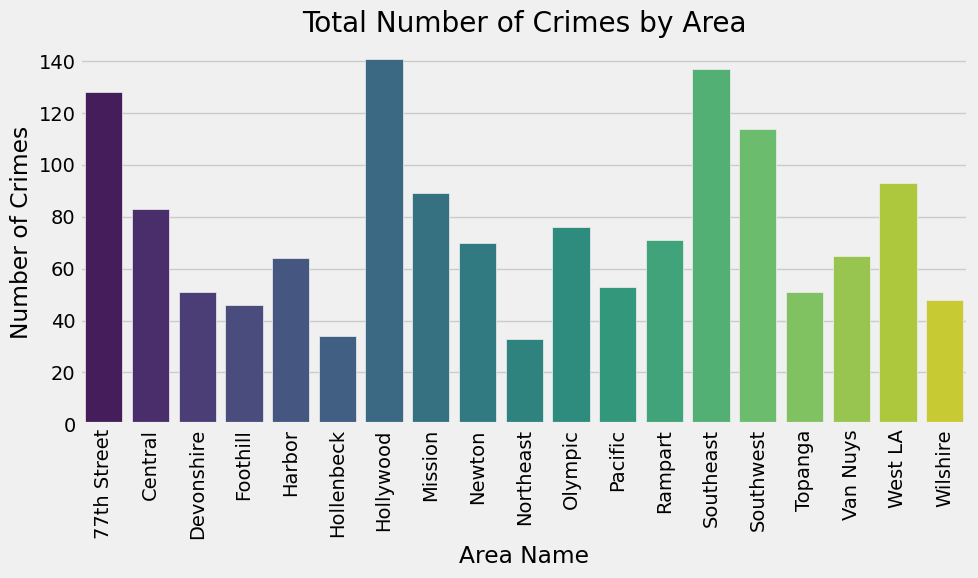

In [ ]:
# Visualize the distribution of crimes across different areas using a bar chart

# Calculating Crime Counts per Area:
crime_counts = clean_data.groupby('Area')['Date'].count().reset_index()
crime_counts.rename(columns={'Date': 'Crime Count'}, inplace=True)
# Creating the Bar Chart:
plt.figure(figsize=(10, 6))
sns.barplot(x='Area', y='Crime Count', data=crime_counts, palette='viridis')
# Adding Labels and Formatting:
plt.title('Total Number of Crimes by Area')
plt.xlabel('Area Name')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<ipython-input-33-ddc94b9e10c9>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x='Type of crime', y='Crime Count', data=crime_counts, palette='rocket')


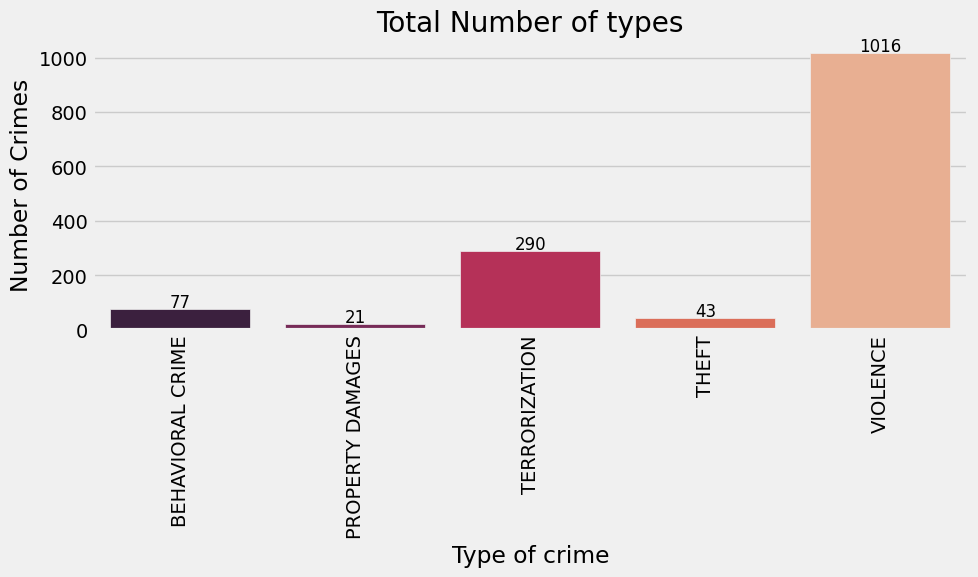

In [ ]:
# Visualize the distribution of crimes across different types using a bar chart

# Calculating Crime Counts:
crime_counts = clean_data.groupby('Type of crime')['Date'].count().reset_index()
crime_counts.rename(columns={'Date': 'Crime Count'}, inplace=True)
# Creating the Bar Chart:
plt.figure(figsize=(10, 6))
ax= sns.barplot(x='Type of crime', y='Crime Count', data=crime_counts, palette='rocket')
# Adding Value Labels to Bars:
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')
# Adding Chart Labels and Formatting:
plt.title('Total Number of types')
plt.xlabel('Type of crime')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

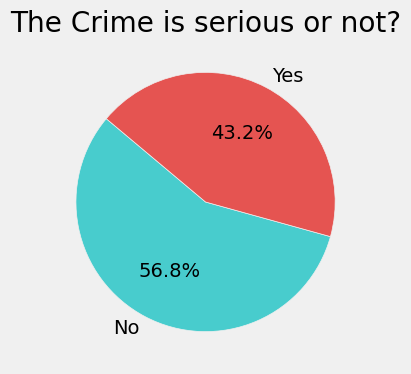

In [ ]:
# Create a pie chart illustrating the distribution of crimes based on their seriousness

# Selects the 'Serious' column
serious_counts = clean_data['Serious'].value_counts()
# Creates the pie chart
plt.figure(figsize=(4, 4))
plt.pie(serious_counts, labels= serious_counts.index,
        autopct='%1.1f%%', startangle=140, colors=['#48CCCD', '#E55451'])
# Sets the title of the pie chart
plt.title('The Crime is serious or not?')
plt.show()

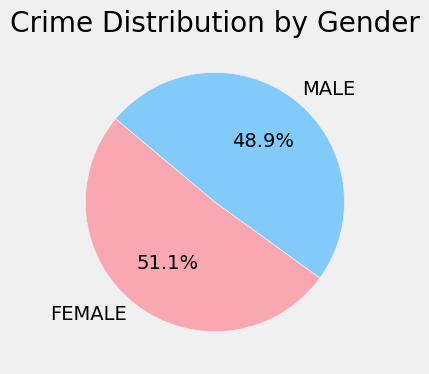

In [ ]:
# Create a pie chart illustrating the distribution of crimes based on gender

# Selects the 'Vict Sex' column
sex_counts = clean_data['Vict Sex'].value_counts()
# Creates the pie chart
plt.figure(figsize=(4, 4))
plt.pie(sex_counts, labels= sex_counts.index,
        autopct='%1.1f%%', startangle=140, colors=['#F9A7B0', '#82CAFA'])
# Sets the title of the pie chart
plt.title('Crime Distribution by Gender')
plt.show()

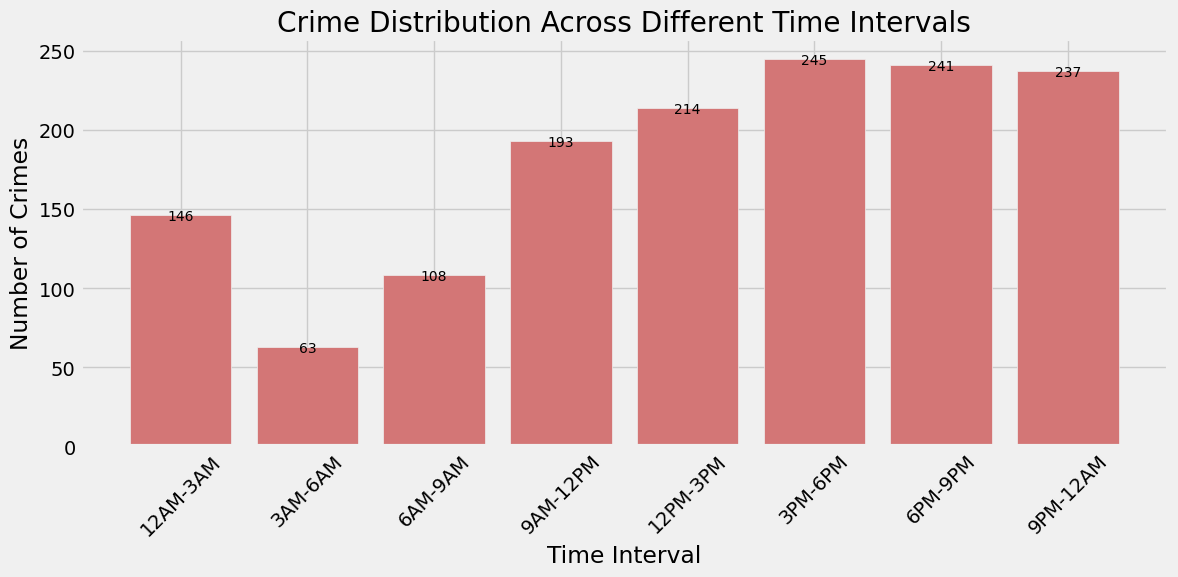

In [ ]:
# Crime Distribution by time of occurence
# Visualize how crimes are distributed throughout the day, using a bar chart

# Define the boundaries for time intervals
TOO = clean_data["Time"]
time_bins = [0, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]
time_labels = ['12AM-3AM', '3AM-6AM', '6AM-9AM', '9AM-12PM',
               '12PM-3PM', '3PM-6PM', '6PM-9PM', '9PM-12AM']
# Categorize the crime times into the defined intervals
TOO = pd.cut(TOO, bins=time_bins, labels=time_labels, right=False)
# Calculating and organizing the number of crimes that occurred within each defined time interval
time_interval_counts = TOO.value_counts().sort_index()
# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(time_interval_counts.index, time_interval_counts.values, color='#D37676')
# Adding count of crimes above each bar in a bar chart
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5,
             str(bar.get_height()), ha='center', va='bottom', fontsize=10)
# Adding Labels and Formatting:
plt.xlabel('Time Interval')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution Across Different Time Intervals')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

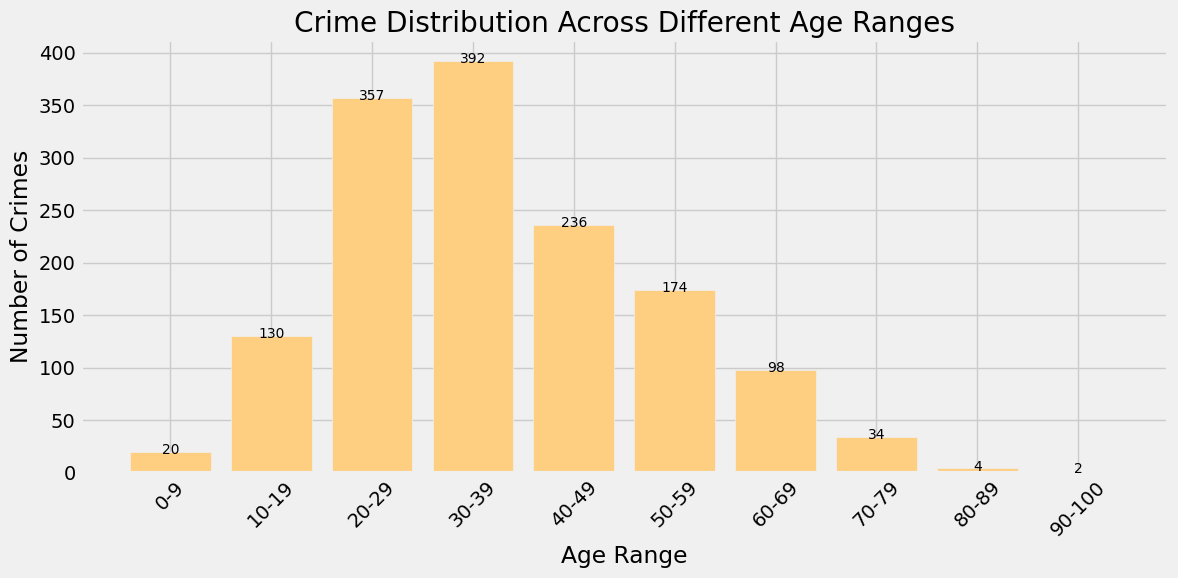

In [ ]:
# Visualize the distribution of crimes based on the age of the victims using bar chart

# Defining Age Bins and Labels:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
age_labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-100']
# Creating DataFrame for Age Ranges:
VA = pd.DataFrame()
VA['Age Range'] = pd.cut(clean_data['Vict Age'], bins=age_bins, labels=age_labels, right=False)
# Calculating Age Distribution:
age_distribution = VA['Age Range'].value_counts().sort_index()
# Creating the Bar Chart:
plt.figure(figsize=(12, 6))
bars = plt.bar(age_distribution.index, age_distribution.values, color='#FFCF81')
# Adding Value Labels to the Bars:
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 5,
             str(bar.get_height()), ha='center', va='bottom', fontsize=10)
# Adding Chart Labels and Formatting:
plt.xlabel('Age Range')
plt.ylabel('Number of Crimes')
plt.title('Crime Distribution Across Different Age Ranges')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Crimes per year:
year
2020      10
2022     255
2024    1182
dtype: int64


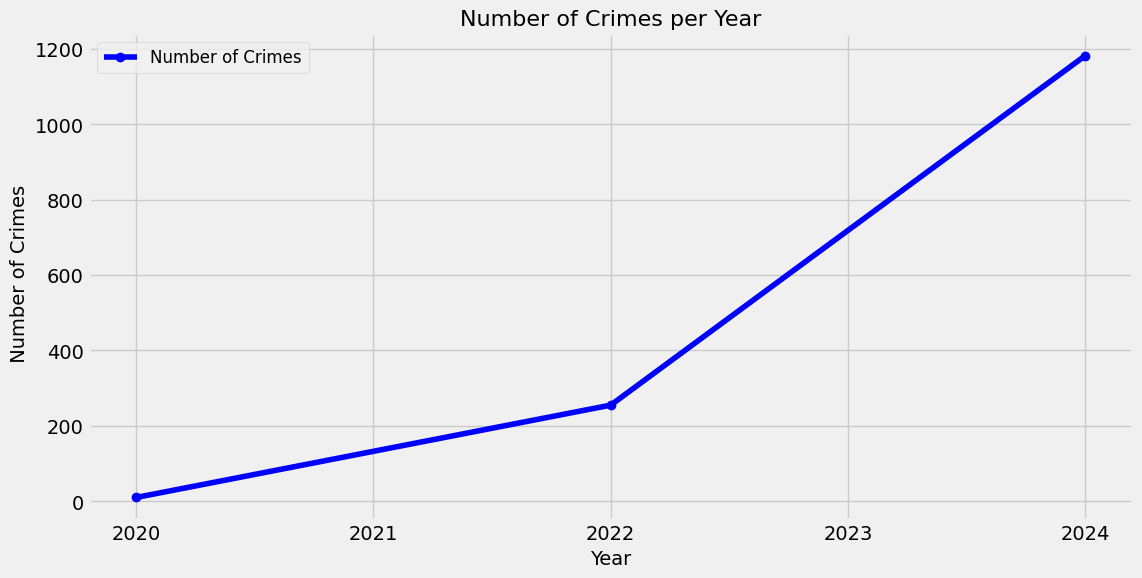

In [ ]:
# Time series distribution of Number of crimes per year

# Create a new DataFrame:
df1 = pd.DataFrame(clean_data)
# Converting 'Date' column into proper datetime format:
df1['Date'] = pd.to_datetime(df1['Date'], format='%m/%d/%Y')
# Creates new column 'year' and populates it with the year extracted from the 'Date' column
df1['year'] = df1['Date'].dt.year
# Selects crime data for years (2020-2024):
years_to_plot = [2020, 2021, 2022, 2023, 2024]
filtered_df1 = df1[df1['year'].isin(years_to_plot)]
# Counts how many crimes occurred in each year:
crime_counts_per_year = filtered_df1.groupby('year').size()
# Printing Crime Counts:
print("Crimes per year:")
print(crime_counts_per_year)
# Creating the Plot:
plt.figure(figsize=(12, 6))
plt.plot(crime_counts_per_year.index, crime_counts_per_year.values, label='Number of Crimes', marker='o', linestyle='-', color='blue')

# Adding Chart Labels and Formatting:
plt.title('Number of Crimes per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel(' Number of Crimes', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.xticks(years_to_plot)
plt.show()

<ipython-input-39-c2f3e2b96ae3>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x='Weapon', y='Crime Count', data=crime_counts, palette='rocket')


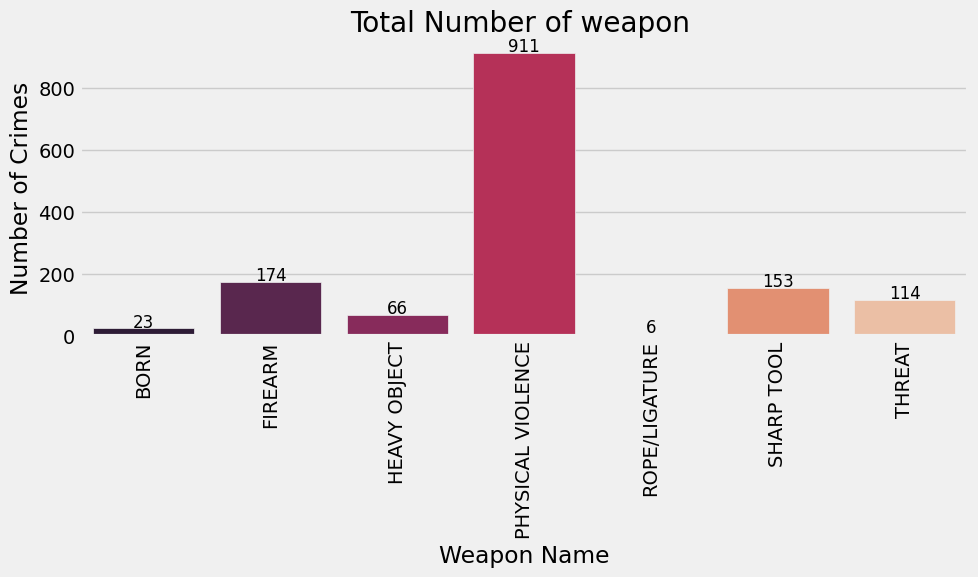

In [ ]:
# Visualize the distribution of crimes based on the Weapon using bar chart

# Calculating Crime Counts:
crime_counts = clean_data.groupby('Weapon')['Date'].count().reset_index()
crime_counts.rename(columns={'Date': 'Crime Count'}, inplace=True)
# Creating the Bar Chart:
plt.figure(figsize=(10, 6))
ax= sns.barplot(x='Weapon', y='Crime Count', data=crime_counts, palette='rocket')
# Adding Value Labels to Bars:
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')
# Adding Chart Labels and Formatting:
plt.title('Total Number of weapon ')
plt.xlabel('Weapon Name')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Provide a basic statistical summary of the 'Vict Age' column

# Creating a DataFrame:
df = pd.DataFrame(clean_data)
# Select numerical features
numerical_features = ['Vict Age']
# Calculate central tendencies and spread
for feature in numerical_features:
    print(f"Feature: {feature}")
    print(f"  Mean: {df[feature].mean()}")
    print(f"  Median: {df[feature].median()}")
    print(f"  Mode: {df[feature].mode()[0]}")  # Mode might return a Series, so we take the first value
    print(f"  Variance: {df[feature].var()}")
    print(f"  Standard Deviation: {df[feature].std()}")
    print("\n")

Feature: Vict Age
  Mean: 37.03939184519696
  Median: 34.0
  Mode: 33
  Variance: 234.4458884265731
  Standard Deviation: 15.31162592367555




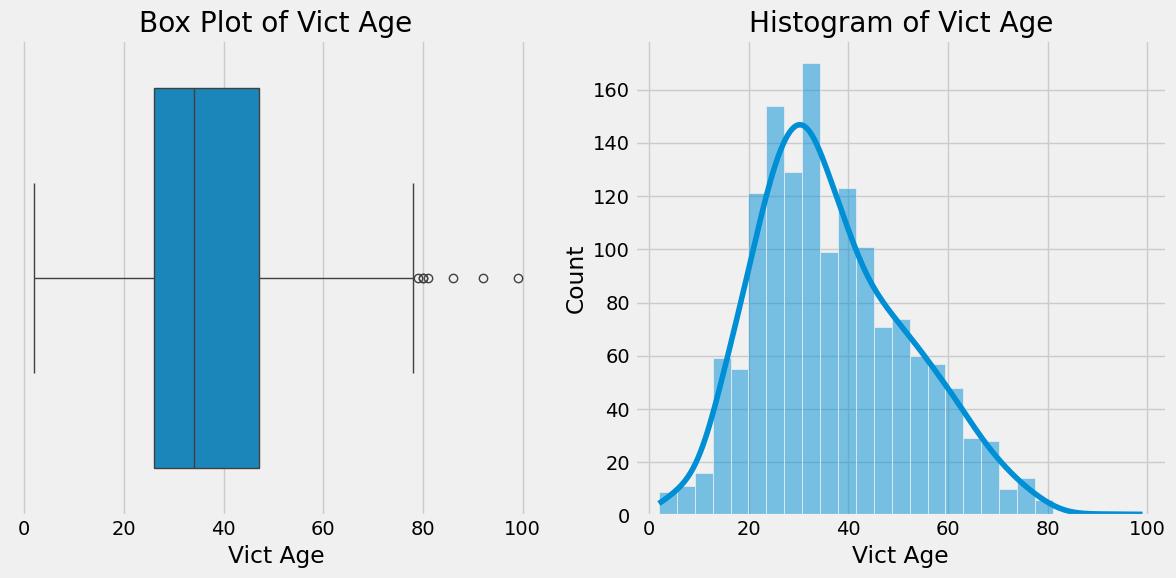

In [ ]:
# Visualize the distribution and statistical properties of Vict Age data using box plot and histogram

# Creating a DataFrame:
df = pd.DataFrame(clean_data)
# Select 'Vict Age' feature
numerical_features = ['Vict Age']
# Create subplots for box plots and histograms
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6 * len(numerical_features)))

for i, feature in enumerate(numerical_features):
    # Box plot
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].title.set_text(f'Box Plot of {feature}')
    # Histogram
    sns.histplot(df[feature], ax=axes[1], kde=True)
    axes[1].title.set_text(f'Histogram of {feature}')
# Displaying Plots:
plt.tight_layout()
plt.show()

## 3.2 Based on multi variables

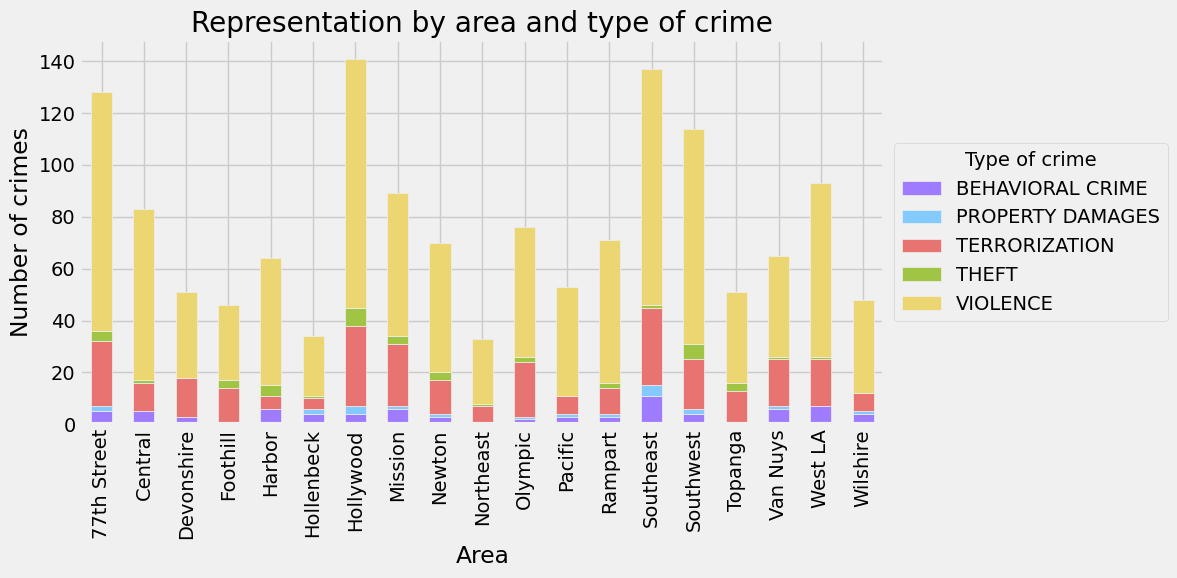

In [ ]:
# Create stacked bar chart that visualizes the relationship between crime types and the areas where they occur

# Data Selection and Transformation:
v2d = clean_data[['Area', 'Type of crime']]
v2d = v2d.pivot_table(index="Area", columns="Type of crime", aggfunc="size", fill_value=0) # Changed aggfunc to 'size'

# Creating the Stacked Bar Chart:
v2d.plot(kind="bar", figsize=(12, 6), stacked= True , color=['#9E7BFF', '#82CAFF', '#E77471', '#A0C544', '#ECD672', '#43BFC7'])

# Adding Chart Labels and Formatting:
plt.title("Representation by area and type of crime")
plt.xlabel("Area")
plt.ylabel("Number of crimes")
plt.legend(title="Type of crime", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

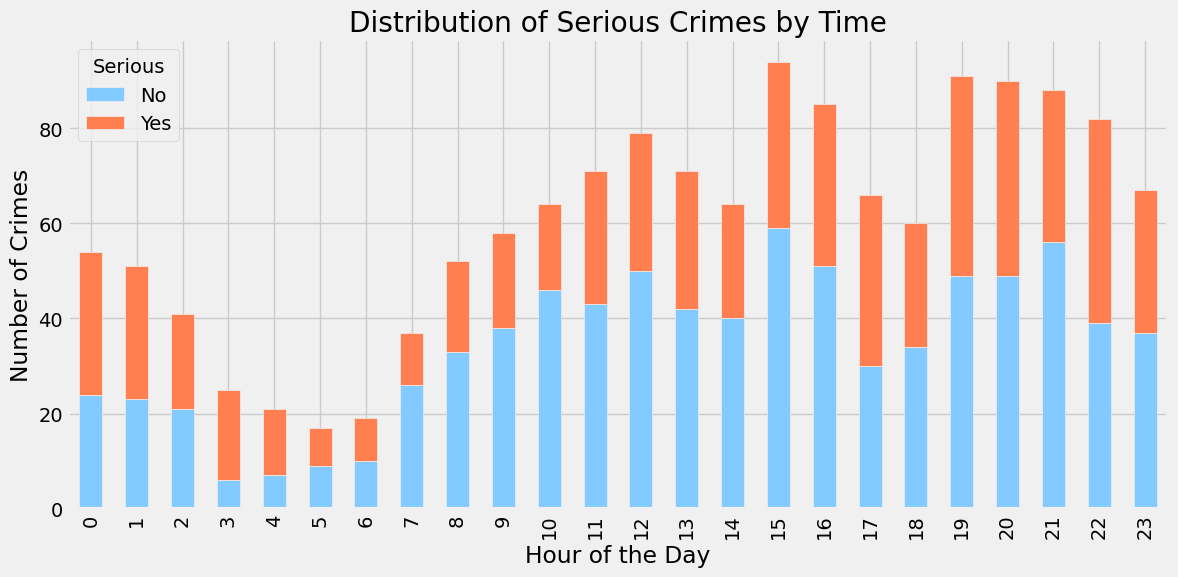

In [ ]:
# Create stacked bar chart to summarizes the number of crimes based on the hour and seriousness level

# Creating DataFrame:
byHour= pd.DataFrame(clean_data)
# Extracting the hour of the crime from 'Time' column and storing it in new 'Hour' column in byHour
byHour['Hour'] = pd.to_datetime(clean_data['Time'].astype(str).str.zfill(4), format='%H%M').dt.hour
# Creating a Pivot Table:
pivot = byHour.pivot_table(index='Hour', columns='Serious', aggfunc='size', fill_value=0)
# Creating and Customizing the Chart:
pivot.plot(kind='bar', figsize=(12, 6), stacked= True, color=['#82CAFF', '#FF7F50'])
plt.title('Distribution of Serious Crimes by Time')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Crimes')
plt.legend(title='Serious')
plt.tight_layout()
plt.show()

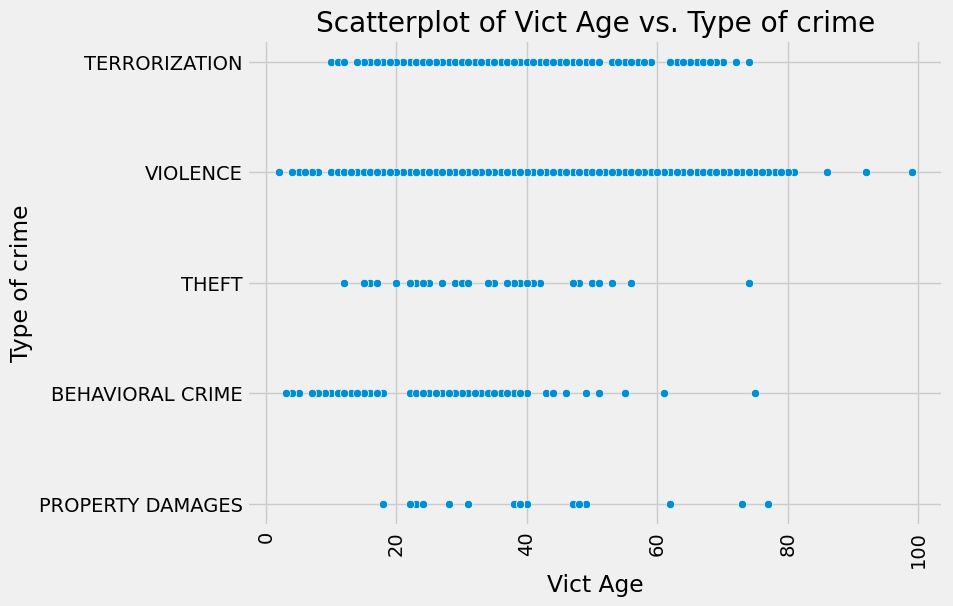

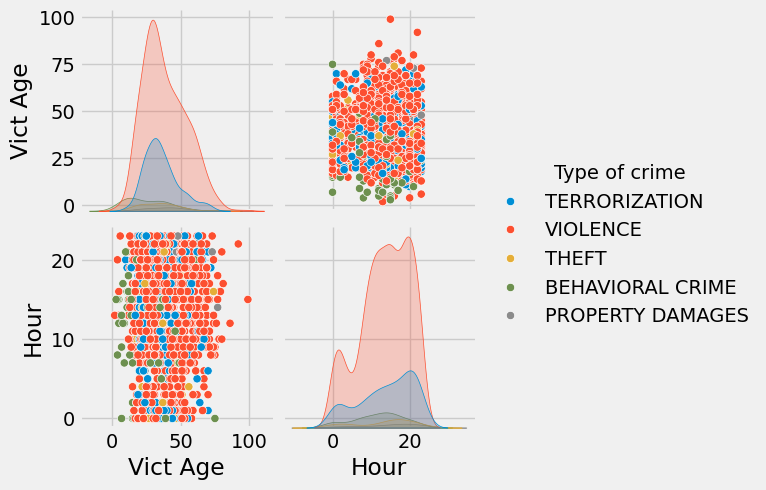

In [ ]:
# Visualizing the relationship between victim's age, type of crime, and hour of the crime using scatterplots and a pair plot

# Creating DataFrame:
df = pd.DataFrame(byHour)

# 1. Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Vict Age', y='Type of crime', data=df)
plt.title('Scatterplot of Vict Age vs. Type of crime')
plt.xticks(rotation=90)
plt.show()

# 2. Pair Plot (for multiple numerical features)
numerical_features = ['Vict Age', 'Hour']
sns.pairplot(df[numerical_features + ['Type of crime']], hue='Type of crime')
plt.show()

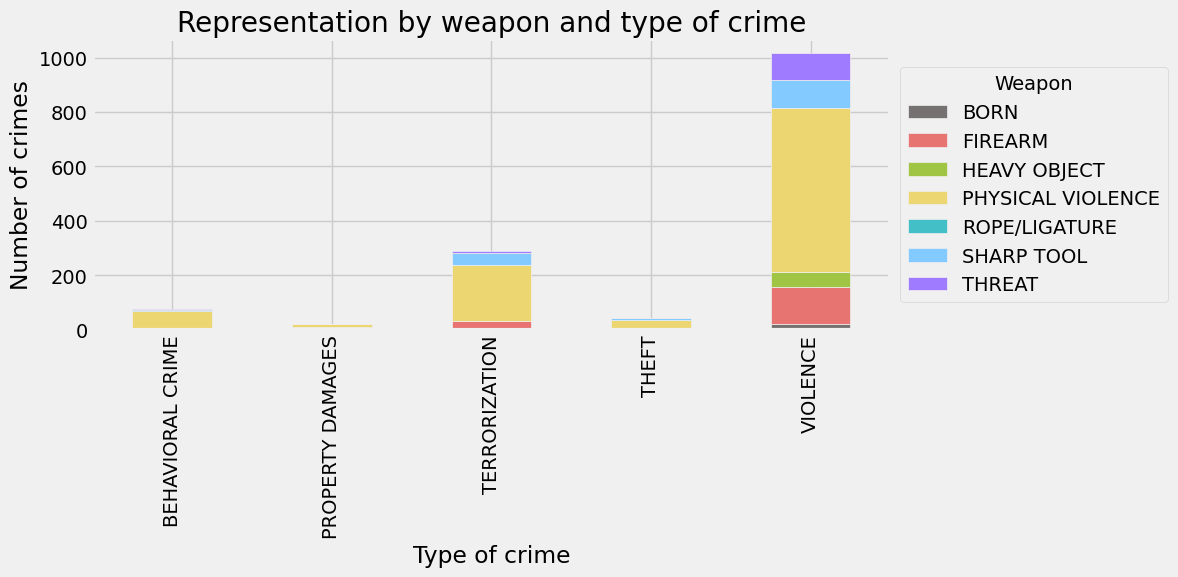

In [ ]:
# Create stacked bar chart that visualizes the relationship between type of crime and weapon used

# Data Selection and Transformation:
v2dW = clean_data[['Type of crime', 'Weapon']]
v2dW = v2dW.pivot_table(index="Type of crime", columns="Weapon", aggfunc="size", fill_value=0)
# Creating the Stacked Bar Chart:
v2dW.plot(kind="bar", figsize=(12, 6), stacked=True, color=['#747170', '#E77471', '#A0C544', '#ECD672', '#43BFC7', '#82CAFF','#9E7BFF'])
# Adding Chart Labels and Formatting:
plt.title("Representation by weapon and type of crime")
plt.xlabel("Type of crime")
plt.ylabel("Number of crimes")
plt.legend(title="Weapon", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

plt.show()

# Modeling

#Modeling by Random Forest Classifier
#Prediction on two variables ['Type of crime', 'Vict Age']

In [ ]:
# Copying clean data and dropping the columns we do not need
modle_data = clean_data.drop(['Time','Status','Time 24-form'], axis=1, errors='ignore')
# Select Hour column from byHour
modle_data['Hour'] = byHour['Hour']
modle_data.head()

,Date,Area,Serious,Type of crime,Vict Age,Vict Sex,Weapon,Hour
0,05/10/2020,Central,No,TERRORIZATION,30,FEMALE,PHYSICAL VIOLENCE,22
1,12/02/2020,77th Street,Yes,VIOLENCE,21,MALE,THREAT,22
2,05/01/2020,77th Street,Yes,VIOLENCE,28,FEMALE,SHARP TOOL,23
3,01/18/2020,Central,No,VIOLENCE,42,MALE,PHYSICAL VIOLENCE,9
4,08/27/2020,Van Nuys,No,VIOLENCE,57,FEMALE,PHYSICAL VIOLENCE,12


In [ ]:
# Feature Selection and Preprocessing:
features = ['Area', 'Date', 'Vict Sex', 'Hour', 'Serious', 'Weapon']
targets = ['Type of crime', 'Vict Age']

X = modle_data[features]
y = modle_data[targets]

In [ ]:
# Data transformtion
# Create LabelEncoder objects for each categorical feature
# Encoding Categorical Features:
categorical_features = ['Area', 'Vict Sex', 'Serious', 'Weapon']
encoders = {}
for feature in categorical_features:
    encoders[feature] = LabelEncoder()
    X[feature] = encoders[feature].fit_transform(X[feature])

# Convert Date to Numerical Features: Year ,Month ,Day
X['Year'] = pd.to_datetime(X['Date'], format='%m/%d/%Y').dt.year
X['Month'] = pd.to_datetime(X['Date'], format='%m/%d/%Y').dt.month
X['Day'] = pd.to_datetime(X['Date'], format='%m/%d/%Y').dt.day

X = X.drop('Date', axis=1)


# Feature Scaling:
scaler = MinMaxScaler()
numerical_features = ['Year', 'Month', 'Day', 'Hour']
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# why we used Normalization scaler"MinMaxScaler"?
# -Less sensitive to outliers compared to StandardScaler.
# -Preserves the shape of the original distribution
#   without distorting the relationships between data points
#   This is important for maintaining the underlying patterns in our data.
# -Improved the performance and convergence of our Random Forest model in predicting crime types and victim ages

X.head()

<ipython-input-48-fe5d549534a5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feature] = encoders[feature].fit_transform(X[feature])
<ipython-input-48-fe5d549534a5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[feature] = encoders[feature].fit_transform(X[feature])
<ipython-input-48-fe5d549534a5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

,Area,Vict Sex,Hour,Serious,Weapon,Year,Month,Day
0,1,0,0.956522,0,3,0.0,0.363636,0.300000
1,0,1,0.956522,1,6,0.0,1.000000,0.033333
2,0,0,1.000000,1,5,0.0,0.363636,0.000000
3,1,1,0.391304,0,3,0.0,0.000000,0.566667
4,16,0,0.521739,0,3,0.0,0.636364,0.866667


In [ ]:
# Data transformtion
# Create LabelEncoder objects for categorical and numerical target variable

le_crime = LabelEncoder()
y['Type of crime'] = le_crime.fit_transform(y['Type of crime'])

y.head()

<ipython-input-49-0b67a887f03c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Type of crime'] = le_crime.fit_transform(y['Type of crime'])


,Type of crime,Vict Age
0,2,30
1,4,21
2,4,28
3,4,42
4,4,57


In [ ]:
# 5. Split Data into Training and Testing Sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Training:
base_model = RandomForestClassifier(n_estimators=100, random_state=42)
model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [ ]:
# 05/10/2020	Central	No	TERRORIZATION	30	FEMALE	PHYSICAL VIOLENCE	22
# 8. Prediction on New Data:
new_data = pd.DataFrame({'Area': ['Central'], 'Year': [2020], 'Month': [10], 'Day': [5], 'Hour': [22],
                         'Vict Sex': ['FEMALE'], 'Serious': ['No'], 'Weapon': ['PHYSICAL VIOLENCE']})

# Reorder the columns to match X_train
new_data = new_data[['Area', 'Vict Sex', 'Hour', 'Serious', 'Weapon', 'Year', 'Month', 'Day']]

# Transform new data using the encoders fitted during training

for feature in categorical_features:
    # Handle unknown labels by adding them to the encoder's classes
    if new_data[feature][0] not in encoders[feature].classes_:
        encoders[feature].classes_ = np.append(encoders[feature].classes_, new_data[feature][0])
    new_data[feature] = encoders[feature].transform(new_data[feature])

new_data[numerical_features] = scaler.transform(new_data[numerical_features])

predicted_values = model.predict(new_data)

# Decode the predictions
predicted_crime_type = le_crime.inverse_transform([predicted_values[0][0]])[0]
predicted_victim_age = predicted_values[0][1]

print(f"\nPredicted Crime Type: {predicted_crime_type}")
print(f"Predicted Victim Age: {predicted_victim_age}")


Predicted Crime Type: TERRORIZATION
Predicted Victim Age: 30


In [ ]:
new_data

,Area,Vict Sex,Hour,Serious,Weapon,Year,Month,Day
0,1,0,0.956522,0,3,0.0,0.818182,0.133333


In [ ]:
predicted_values

array([[ 2, 30]])